In [1]:
# Cell 1: Imports and Device Setup
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import random
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import os
from tqdm import tqdm

device = torch.device('cpu')
print("Using device:", device)

Using device: cpu


In [2]:
# Cell 2: Custom Dataset and Transformations
class MonitorDataset(Dataset):
    """Custom Dataset for loading monitor images from a folder."""
    def __init__(self, img_dir, transform=None):
        self.img_dir = img_dir
        self.transform = transform
        self.image_paths = [
            os.path.join(img_dir, f) for f in os.listdir(img_dir)
            if f.endswith(('.jpg', '.jpeg', '.png'))
        ]
    
    def __len__(self):
        return len(self.image_paths)
    
    def __getitem__(self, idx):
        img = Image.open(self.image_paths[idx]).convert('RGB')
        if self.transform:
            img = self.transform(img)
        return img

# Image transforms: resize to 64x64 and convert to tensor (values in [0,1])
transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
])

In [3]:
# Cell 3: VAE Model Definition
class VAE(nn.Module):
    def __init__(self, latent_dim=32):
        super().__init__()
        
        # Encoder
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),
            nn.Flatten()
        )
        # After two conv+pooling, size: 64 x 16 x 16
        self.fc_mu = nn.Linear(64 * 16 * 16, latent_dim)
        self.fc_logvar = nn.Linear(64 * 16 * 16, latent_dim)
        
        # Decoder
        self.fc_decode = nn.Linear(latent_dim, 64 * 16 * 16)
        self.decoder = nn.Sequential(
            nn.Unflatten(1, (64, 16, 16)),
            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(32, 3, kernel_size=4, stride=2, padding=1),
            nn.Sigmoid()   # output in [0,1]
        )
    
    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std
    
    def forward(self, x):
        encoded = self.encoder(x)
        mu = self.fc_mu(encoded)
        logvar = self.fc_logvar(encoded)
        z = self.reparameterize(mu, logvar)
        recon = self.decoder(self.fc_decode(z))
        return recon, mu, logvar

In [4]:
# Cell 4: Loss Functions (BCE and MSE)
def vae_loss_bce(recon_x, x, mu, logvar):
    """Binary Cross Entropy reconstruction loss + KL divergence."""
    recon_loss = nn.functional.binary_cross_entropy(recon_x, x, reduction='sum')
    kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return recon_loss + kl_loss

def vae_loss_mse(recon_x, x, mu, logvar):
    """Mean Squared Error reconstruction loss + KL divergence."""
    recon_loss = nn.functional.mse_loss(recon_x, x, reduction='sum')
    kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return recon_loss + kl_loss

In [5]:
# Cell 5: Load Dataset and Create DataLoader
# Update this path to your dataset location
dataset = MonitorDataset(
    img_dir="/home/saidul/Desktop/4-2/Deep Learning/data/Computer_monitor",
    transform=transform
)
dataloader = DataLoader(dataset, batch_size=8, shuffle=True)  # small batch for CPU
print(f"Total images: {len(dataset)}")

Total images: 34


In [6]:
# Cell 6: Initial Training (50 epochs, BCE loss)
model = VAE(latent_dim=32).to(device)
optimizer = optim.Adam(model.parameters(), lr=0.001)

print("Starting VAE Training on Monitor Images...")
for epoch in range(50):
    total_loss = 0
    for batch in tqdm(dataloader, desc=f"Epoch {epoch+1}/50"):
        batch = batch.to(device)
        optimizer.zero_grad()
        recon, mu, logvar = model(batch)
        loss = vae_loss_bce(recon, batch, mu, logvar)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    
    avg_loss = total_loss / len(dataloader)
    print(f"Epoch {epoch+1}/50 - Average Loss: {avg_loss:.2f}")

Starting VAE Training on Monitor Images...


Epoch 1/50: 100%|██████████| 5/5 [00:01<00:00,  3.71it/s]


Epoch 1/50 - Average Loss: 57935.84


Epoch 2/50: 100%|██████████| 5/5 [00:01<00:00,  4.43it/s]


Epoch 2/50 - Average Loss: 57292.44


...

Epoch 48/50 - Average Loss: 41664.69


Epoch 49/50: 100%|██████████| 5/5 [00:01<00:00,  4.08it/s]


Epoch 49/50 - Average Loss: 41452.57


Epoch 50/50: 100%|██████████| 5/5 [00:01<00:00,  4.07it/s]

Epoch 50/50 - Average Loss: 41401.66


In [7]:
# Cell 7: Save the Trained Model
torch.save(model.state_dict(), "vae_monitor_model.pth")
print("Model saved as 'vae_monitor_model.pth'")

Model saved as 'vae_monitor_model.pth'


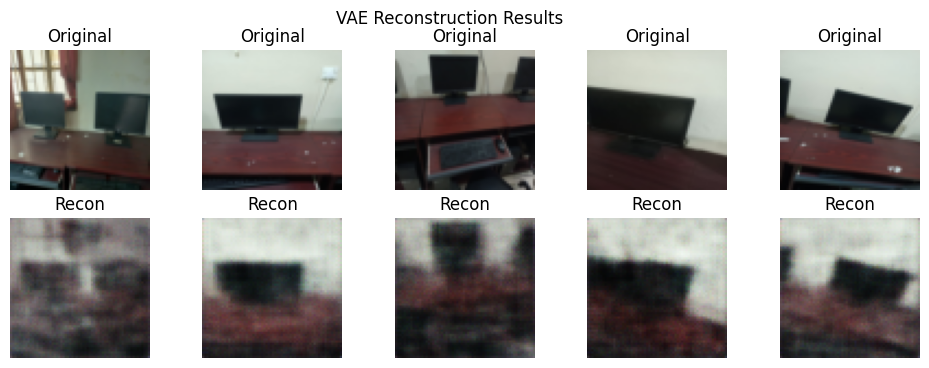

In [8]:
# Cell 8: Visualize Reconstructions on a Batch
def show_reconstructions(model, dataloader, n=5):
    model.eval()
    with torch.no_grad():
        for batch in dataloader:
            batch = batch.to(device)
            recon, _, _ = model(batch)
            
            plt.figure(figsize=(12, 4))
            for i in range(n):
                # Original
                plt.subplot(2, n, i+1)
                plt.imshow(batch[i].cpu().permute(1, 2, 0))
                plt.title("Original")
                plt.axis('off')
                
                # Reconstructed
                plt.subplot(2, n, i+1+n)
                plt.imshow(recon[i].cpu().permute(1, 2, 0))
                plt.title("Recon")
                plt.axis('off')
            plt.suptitle("VAE Reconstruction Results")
            plt.show()
            break  # show only first batch

show_reconstructions(model, dataloader)

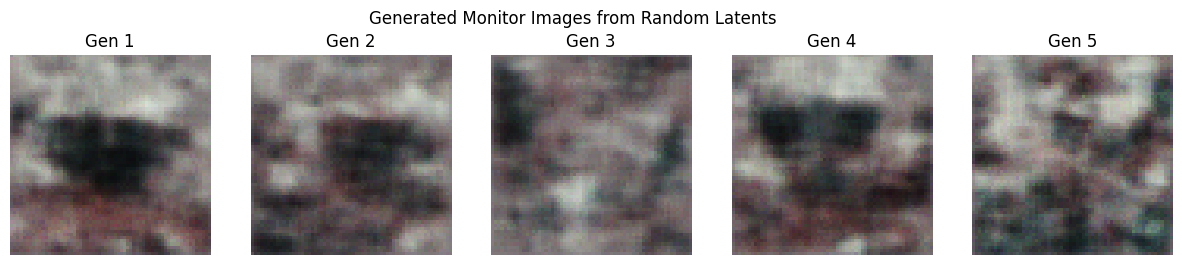

In [9]:
# Cell 9: Generate New Monitor Images from Random Latent Vectors
def generate_new_monitors(model, num_images=5, latent_dim=32):
    model.eval()
    with torch.no_grad():
        z = torch.randn(num_images, latent_dim).to(device)
        generated = model.decoder(model.fc_decode(z))
        
        plt.figure(figsize=(15, 3))
        for i in range(num_images):
            plt.subplot(1, num_images, i+1)
            plt.imshow(generated[i].cpu().permute(1, 2, 0))
            plt.title(f"Gen {i+1}")
            plt.axis('off')
        plt.suptitle("Generated Monitor Images from Random Latents")
        plt.show()

generate_new_monitors(model)

In [10]:
# Cell 10: Compare BCE vs MSE Reconstruction Losses
# Train two separate models with different reconstruction losses (30 epochs each)

# ---------- BCE-based VAE ----------
model_bce = VAE(latent_dim=32).to(device)
optimizer_bce = optim.Adam(model_bce.parameters(), lr=0.001)

print("Training VAE with BCE Loss...")
for epoch in range(30):
    total_loss = 0
    for batch in tqdm(dataloader, desc=f"BCE Epoch {epoch+1}/30"):
        batch = batch.to(device)
        recon, mu, logvar = model_bce(batch)
        loss = vae_loss_bce(recon, batch, mu, logvar)
        optimizer_bce.zero_grad()
        loss.backward()
        optimizer_bce.step()
        total_loss += loss.item()
    print(f"BCE Epoch {epoch+1}/30 - Avg Loss: {total_loss/len(dataloader):.2f}")

# ---------- MSE-based VAE ----------
model_mse = VAE(latent_dim=32).to(device)
optimizer_mse = optim.Adam(model_mse.parameters(), lr=0.001)

print("\nTraining VAE with MSE Loss...")
for epoch in range(30):
    total_loss = 0
    for batch in tqdm(dataloader, desc=f"MSE Epoch {epoch+1}/30"):
        batch = batch.to(device)
        recon, mu, logvar = model_mse(batch)
        loss = vae_loss_mse(recon, batch, mu, logvar)
        optimizer_mse.zero_grad()
        loss.backward()
        optimizer_mse.step()
        total_loss += loss.item()
    print(f"MSE Epoch {epoch+1}/30 - Avg Loss: {total_loss/len(dataloader):.2f}")

Training VAE with BCE Loss...


BCE Epoch 1/30: 100%|██████████| 5/5 [00:01<00:00,  4.24it/s]


BCE Epoch 1/30 - Avg Loss: 58952.08


BCE Epoch 2/30: 100%|██████████| 5/5 [00:01<00:00,  3.71it/s]


BCE Epoch 2/30 - Avg Loss: 58077.15


...

MSE Epoch 28/30 - Avg Loss: 1451.58


MSE Epoch 29/30: 100%|██████████| 5/5 [00:01<00:00,  4.93it/s]


MSE Epoch 29/30 - Avg Loss: 1321.26


MSE Epoch 30/30: 100%|██████████| 5/5 [00:01<00:00,  4.78it/s]

MSE Epoch 30/30 - Avg Loss: 1261.81


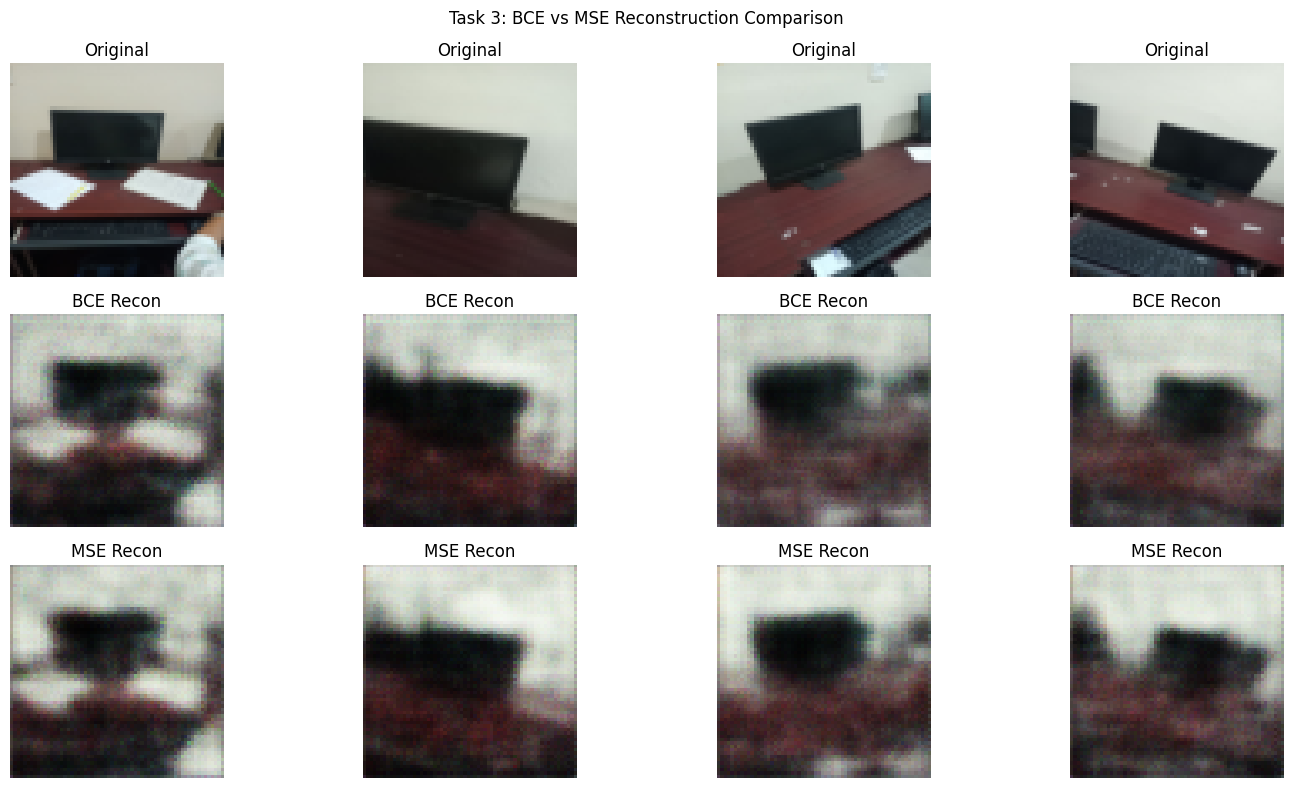

In [11]:
# Cell 11: Visual Comparison of BCE vs MSE Reconstructions
model_bce.eval()
model_mse.eval()

# Pick 4 random images from the dataset
samples = [dataset[i] for i in random.sample(range(len(dataset)), 4)]

plt.figure(figsize=(15, 8))
for i, img in enumerate(samples):
    img_tensor = img.unsqueeze(0).to(device)
    
    with torch.no_grad():
        recon_bce, _, _ = model_bce(img_tensor)
        recon_mse, _, _ = model_mse(img_tensor)
    
    # Original
    plt.subplot(3, 4, i+1)
    plt.imshow(img.permute(1, 2, 0))
    plt.title("Original")
    plt.axis('off')
    
    # BCE reconstruction
    plt.subplot(3, 4, i+5)
    plt.imshow(recon_bce.cpu().squeeze().permute(1, 2, 0))
    plt.title("BCE Recon")
    plt.axis('off')
    
    # MSE reconstruction
    plt.subplot(3, 4, i+9)
    plt.imshow(recon_mse.cpu().squeeze().permute(1, 2, 0))
    plt.title("MSE Recon")
    plt.axis('off')

plt.suptitle("Task 3: BCE vs MSE Reconstruction Comparison")
plt.tight_layout()
plt.show()